Saving Experiments_5_7_ML_Dataset.csv to Experiments_5_7_ML_Dataset (1).csv
Dataset shape: (500, 9)


,StudyHours,Attendance,AssignmentsCompleted,PreviousScore,SleepHours,InternetUsageHours,PracticeTests,FinalScore,PlacementStatus
0,4.37,86.42,9,51.86,7.18,4.17,0,85.58,1
1,9.56,79.12,4,76.24,7.93,3.51,1,101.26,1
2,7.59,68.93,9,61.66,4.59,7.95,10,101.35,1
3,6.39,91.62,6,75.82,6.05,7.10,8,109.08,1
4,2.40,85.81,2,45.86,8.20,5.18,8,67.22,0



 Ridge Regression
MAE  : 3.693
RMSE : 4.634
R2   : 0.907

 Lasso Regression
MAE  : 3.714
RMSE : 4.656
R2   : 0.906

 Elastic Net
MAE  : 3.815
RMSE : 4.796
R2   : 0.9

Model Comparison


,Model,MAE,RMSE,R2 Score
0,Ridge,3.692702,4.634281,0.906825
1,Lasso,3.713824,4.655630,0.905965
2,Elastic Net,3.814742,4.795914,0.900212


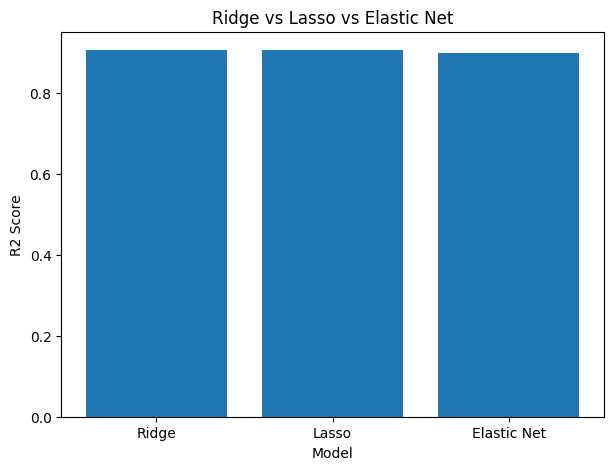


Model Coefficients


,Feature,Ridge,Lasso,Elastic Net
0,StudyHours,10.170596,10.096407,9.659209
1,Attendance,2.953254,2.859327,2.777880
2,AssignmentsCompleted,4.440349,4.338360,4.148524
3,PreviousScore,6.786745,6.705201,6.414570
4,SleepHours,1.724574,1.643130,1.636838
5,InternetUsageHours,-2.118404,-2.025603,-1.978572
6,PracticeTests,5.451699,5.365315,5.162726


In [2]:
# ============================================
# EXPERIMENT 5
# Ridge, Lasso and Elastic Net Regularisation
# ============================================

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Step 2: Upload CSV
uploaded = files.upload()

# Step 3: Read dataset
df = pd.read_csv("Experiments_5_7_ML_Dataset.csv")

print("Dataset shape:", df.shape)
display(df.head())

# Step 4: Select features and target
X = df.drop(columns=["FinalScore", "PlacementStatus"])
y = df["FinalScore"]

# Step 5: Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Standardize features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 7: Create models
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)

# Step 8: Train models
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)
elastic.fit(X_train_scaled, y_train)

# Step 9: Make predictions
ridge_pred = ridge.predict(X_test_scaled)
lasso_pred = lasso.predict(X_test_scaled)
elastic_pred = elastic.predict(X_test_scaled)

# Step 10: Evaluation function
def evaluate_model(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("\n", name)
    print("MAE  :", round(mae, 3))
    print("RMSE :", round(rmse, 3))
    print("R2   :", round(r2, 3))

    return [mae, rmse, r2]

ridge_result = evaluate_model("Ridge Regression", y_test, ridge_pred)
lasso_result = evaluate_model("Lasso Regression", y_test, lasso_pred)
elastic_result = evaluate_model("Elastic Net", y_test, elastic_pred)

# Step 11: Compare results
results = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "Elastic Net"],
    "MAE": [
        ridge_result[0],
        lasso_result[0],
        elastic_result[0]
    ],
    "RMSE": [
        ridge_result[1],
        lasso_result[1],
        elastic_result[1]
    ],
    "R2 Score": [
        ridge_result[2],
        lasso_result[2],
        elastic_result[2]
    ]
})

print("\nModel Comparison")
display(results)

# Step 12: Plot R2 scores
plt.figure(figsize=(7,5))

plt.bar(results["Model"], results["R2 Score"])

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Ridge vs Lasso vs Elastic Net")

plt.show()

# Step 13: Compare coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "Elastic Net": elastic.coef_
})

print("\nModel Coefficients")
display(coefficients)